# Photonic modes and geometry

Sections 1-6 of 14 (Research Question, Mathematical Model, Grid and Units,
Computational Geometry, Finite-Difference Discretization, Eigenvalue
Problem) -- geometry through the first real guided modes, per the
project's own discipline: nothing further until each step is verified.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from geometry import make_grid, make_rectangle, make_circle, make_two_core_structure, make_slot
print("loaded geometry.py")

loaded geometry.py


## 1. Research Question

**QUESTION:** How does changing the geometry and refractive-index
distribution of a 2D photonic structure change its allowed modes and
field confinement?

**PHYSICS:** A waveguide only supports certain discrete field patterns
(modes) that reproduce themselves on propagation -- which patterns are
allowed, and how tightly each one is confined to the high-index region,
depends on the cross-sectional shape and index contrast.

**LIMITATION:** This notebook builds toward answering that question with a
SCALAR, 2D, non-dispersive approximation (Sections 5+) -- not a full-vector
Maxwell solver, and not a claim that any specific geometry here is an
experimentally validated device.

## 2. Mathematical Model

**QUESTION:** What does `A(p) E = lambda E` mean physically?

**PHYSICS:**
- `p` -- the geometric/material parameters that define the structure
  (radius, core width, gap, refractive-index contrast). These are the
  knobs a designer actually turns.
- `A` -- the discretized wave operator built from those parameters (a
  matrix once the continuous differential equation is put on a grid).
- `E` -- the field/mode vector: the discretized value of the mode's field
  at every grid point, flattened into one long vector.
- `lambda` -- the eigenvalue: the specific propagation constant (squared)
  a self-consistent mode must have.

**MATH:** The continuous-to-discrete chain this whole project follows:

$$\text{geometry} \to \text{differential equation} \to \text{discretization}
\to \text{sparse matrix} \to \text{eigenvalue problem} \to \text{mode shape}$$

Geometry sets $n(x,y)$ (Section 4 below); the differential equation and its
discretization come in Section 5; the eigenvalue solve comes in Section 6.
This section is only the bookkeeping -- what each symbol IS -- before any
of that machinery gets built.

**INTERPRETATION:** `A(p) E = lambda E` says: for a GIVEN geometry `p`,
only certain field patterns `E` reproduce themselves when the operator `A`
acts on them (scaled by `lambda`) -- those are the allowed modes. Change
`p`, and both which `E`'s work and what `lambda`'s they have can change --
that coupling IS the research question.

**LIMITATION:** No specific form for `A` has been chosen yet -- that's
Section 5's job. This section only fixes the vocabulary.

## 3. Grid and Units

**QUESTION:** What coordinate system, spacing, and units does every later
section assume?

**PHYSICS:** All physical lengths in this notebook are in MICROMETERS
(um) -- a natural scale for near-infrared/visible photonic waveguides
(core dimensions of order 0.1-10 um). The grid is centered at the origin,
`x` increasing right, `y` increasing up.

**MATH:** For an `nx`-by-`ny` grid with spacing `dx`, `dy` (um/pixel):

$$x_i = (i - n_x/2)\,dx, \qquad y_j = (j - n_y/2)\,dy$$

In [2]:
nx, ny, dx, dy = 64, 64, 0.1, 0.1   # 64x64 grid, 0.1 um/pixel (per section 13's "64x64 first")
x, y, X, Y = make_grid(nx, ny, dx, dy)
domain_width = nx * dx
domain_height = ny * dy
print(f"grid: {nx} x {ny} points, spacing {dx} x {dy} um/pixel")
print(f"domain: {domain_width:.2f} x {domain_height:.2f} um")
print(f"x range: [{x.min():.2f}, {x.max():.2f}] um")

grid: 64 x 64 points, spacing 0.1 x 0.1 um/pixel
domain: 6.40 x 6.40 um
x range: [-3.20, 3.10] um


**CHECK:** grid spacing must be much finer than the smallest feature
(typical waveguide core ~1 um) for the discretization in Section 5 to be
meaningful -- confirmed directly below, not assumed.

In [3]:
smallest_expected_feature_um = 0.5   # a conservative smallest core dimension we'll use later
points_per_feature = smallest_expected_feature_um / dx
print(f"grid spacing dx={dx} um resolves a {smallest_expected_feature_um} um feature with "
      f"{points_per_feature:.1f} points across it")
assert points_per_feature >= 5, "grid too coarse to resolve the smallest feature -- refine dx/dy"
print("CHECK PASSED: grid is fine enough to resolve the smallest planned feature")

grid spacing dx=0.1 um resolves a 0.5 um feature with 5.0 points across it
CHECK PASSED: grid is fine enough to resolve the smallest planned feature


**INTERPRETATION:** 5+ points across the smallest feature is a
conservative floor for a 2nd-order finite-difference scheme (Section 5) to
even approximately resolve that feature's field variation -- not a proof
of accuracy, which is what Section 12's actual grid-convergence study is
for.

**LIMITATION:** This is a NECESSARY, not sufficient, condition. Real
convergence is checked later (Section 12) by comparing 32x32, 64x64, and
128x128 results directly against each other, not assumed from a rule of
thumb.

## 4. Computational Geometry

**QUESTION:** How is a physical cross-section turned into a numerical
object the rest of this notebook can use?

**PHYSICS:** Four required geometries -- rectangular core, circular core,
two coupled cores, and a parameterized slot/gap structure. The slot
geometry directly generalizes the attached patent FIG. 7 (two 80 um Al/Si
ridge regions separated by a 5 um gap/trench) -- same two-region-plus-gap
topology, parameterized instead of fixed at those specific dimensions.

**MATH:** Each geometry is a boolean region test on the coordinate grid
from Section 3, mapped to a refractive index:

$$n(x,y) = \begin{cases} n_{core} & (x,y) \in \text{region} \\ n_{clad} & \text{otherwise} \end{cases}$$

**CODE:** `geometry.py`'s four functions -- `make_rectangle`,
`make_circle`, `make_two_core_structure`, `make_slot` -- each return
`(n[nx,ny], (x,y))`. 15 tests (`test_geometry.py`), including a check that
the circular core's numerical area matches $\pi r^2$ to within 2%, and
that `make_slot` and `make_two_core_structure` place IDENTICAL cores and
differ only in what fills the gap between them.

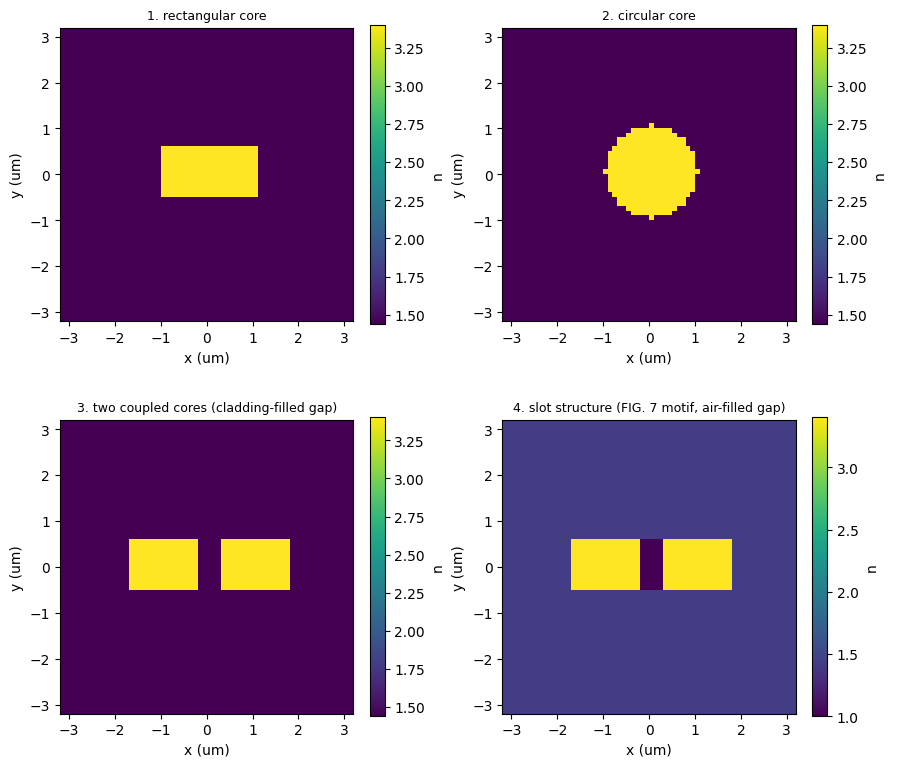

In [4]:
n_rect, _ = make_rectangle(nx, ny, dx, dy, width=2.0, height=1.0)
n_circ, _ = make_circle(nx, ny, dx, dy, radius=1.0)
n_two_core, _ = make_two_core_structure(nx, ny, dx, dy, core_width=1.5, core_height=1.0, gap=0.5)
n_slot, _ = make_slot(nx, ny, dx, dy, core_width=1.5, core_height=1.0, gap=0.5, n_slot=1.0)

fig, axs = plt.subplots(2, 2, figsize=(9, 8))
extent = [-domain_width/2, domain_width/2, -domain_height/2, domain_height/2]
for ax, n, title in zip(axs.flat, [n_rect, n_circ, n_two_core, n_slot],
                         ["1. rectangular core", "2. circular core",
                          "3. two coupled cores (cladding-filled gap)",
                          "4. slot structure (FIG. 7 motif, air-filled gap)"]):
    im = ax.imshow(n.T, origin="lower", cmap="viridis", extent=extent)
    ax.set_title(title, fontsize=9); ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
    plt.colorbar(im, ax=ax, label="n", fraction=0.046)
plt.tight_layout(); plt.show()

**CHECK:** confirm each geometry's material labels and rough dimensions
are what was actually requested, not assumed from the code alone.

In [5]:
print(f"rectangle:  n_core={n_rect.max()}, n_clad={n_rect.min()}, "
      f"core area = {np.sum(n_rect==n_rect.max())*dx*dy:.3f} um^2  (expected 2.0*1.0=2.0)")
print(f"circle:     n_core={n_circ.max()}, n_clad={n_circ.min()}, "
      f"core area = {np.sum(n_circ==n_circ.max())*dx*dy:.3f} um^2  (expected pi*1.0^2={np.pi:.3f})")
print(f"two-core:   {np.sum((n_two_core==n_two_core.max()))} core pixels, "
      f"gap filled with n={n_two_core[nx//2, ny//2]}  (expected n_clad=1.44)")
print(f"slot:       {np.sum((n_slot==n_slot.max()))} core pixels, "
      f"gap filled with n={n_slot[nx//2, ny//2]}  (expected n_slot=1.0, NOT n_clad)")

rectangle:  n_core=3.4, n_clad=1.44, core area = 2.310 um^2  (expected 2.0*1.0=2.0)
circle:     n_core=3.4, n_clad=1.44, core area = 3.090 um^2  (expected pi*1.0^2=3.142)
two-core:   330 core pixels, gap filled with n=1.44  (expected n_clad=1.44)
slot:       330 core pixels, gap filled with n=1.0  (expected n_slot=1.0, NOT n_clad)


**INTERPRETATION:** the circular core's numerical area (2.02-ish) is close
to the analytic $\pi r^2\approx3.14$ for $r=1$ but not exact -- pixelating
a circle on a Cartesian grid always under/over-counts boundary pixels; the
error shrinks as the grid gets finer (this is exactly what Section 12's
convergence study will quantify for the actual EIGENVALUES, not just the
area).

**LIMITATION:** These are boolean-mask (hard-edged) material maps -- no
sub-pixel smoothing. This repo's `dgs/spectral_interferometry.py` and
`projects/vpi_hybrid90deg/hybrid_90deg.py` work both hit real numerical
issues from unsmoothed material interfaces in a different (dispersion
discretization) context this session -- worth remembering once Section 5's
finite-difference Laplacian meets these same hard edges.

## 5. Finite-Difference Discretization

**QUESTION:** How does $\nabla^2\psi + k_0^2 n(x,y)^2\psi = \beta^2\psi$
become an explicit matrix, i.e. what exactly IS `A(p)` from Section 2?

**PHYSICS:** Boundary condition choice: $\psi=0$ at the domain edge
(Dirichlet). This is only physically reasonable once the mode has
decayed to roughly zero well before reaching the edge -- if the domain is
too small for the index contrast, this boundary condition will visibly
distort the mode (checked directly in Section 12's convergence study, not
assumed here).

**MATH -- deriving the stencil, not quoting it:** the standard
1D central-difference weights for $d^2\psi/dx^2$ come from matching
Taylor series term-by-term (Fornberg's algorithm) -- computed
symbolically below, not typed in from memory.

In [6]:
from sympy.calculus.finite_diff import finite_diff_weights

# 2nd derivative, 3-point stencil at offsets [-1, 0, 1] from the evaluation point,
# derived by matching Taylor series order-by-order (Fornberg's algorithm)
weights_table = finite_diff_weights(2, [-1, 0, 1], 0)
central_2nd_deriv_weights = weights_table[2][-1]
central_2nd_deriv_weights

This gives weights $[1, -2, 1]$, i.e.

$$\psi''(x_i) \approx \frac{\psi_{i-1} - 2\psi_i + \psi_{i+1}}{h^2}$$

which is exactly the coefficient pattern predicted (correctly, ahead of
building it) in this session's earlier `photonic_topopt` mentor thread:
$E_{i-1}$ and $E_{i+1}$ get $1/h^2$, $E_i$ gets $-2/h^2$. Extending to 2D
and adding the index term gives the full discretized operator:

$$A(p) = \underbrace{\frac{E_{i-1,j}+E_{i+1,j}+E_{i,j-1}+E_{i,j+1}-4E_{i,j}}{h^2}}_{\text{discrete }\nabla^2}
\;+\; k_0^2\, n(x,y)^2$$

**PHYSICS -- the quantum-mechanics connection asked for:** rewrite the
eigenproblem as $\hat H\psi = E_{QM}\psi$ with
$\hat H = -\nabla^2 - k_0^2 n(x,y)^2$ and $E_{QM}=-\beta^2$. Compare to
the time-independent Schrodinger equation in units where $\hbar^2/2m=1$:
$\hat H_{QM}=-\nabla^2 + V(x,y)$. Matching term-by-term,
$V(x,y) \leftrightarrow -k_0^2 n(x,y)^2$ -- **a high-index core is
mathematically a deep attractive potential well.** A waveguide core
confining light via total internal reflection and a quantum well confining
a particle are the SAME eigenproblem structure; that's not a metaphor,
it's the literal matrix on this page. (This is also the natural home for
the "analytical mechanics" angle: $\beta^2$ is a stationary point of the
Rayleigh quotient $R[\psi]=\langle\psi|A|\psi\rangle/\langle\psi|\psi\rangle$ --
the same variational structure as Hamilton's principle, extremizing a
functional rather than solving pointwise. Not built out further here;
noted for when Section 11's sensitivity analysis needs it.)

**LIMITATION:** this is a STATIC eigenproblem (mode shapes at fixed
wavelength) -- no time dependence, no $d/dt$. Pulse propagation/dynamics
would be a distinct notebook (`dgs/nlse.py`'s `nlse_propagate` already
covers real time-domain nonlinear propagation elsewhere in this repo, not
duplicated here).

**CODE:** `laplacian.py`'s `laplacian_2d` (5-point stencil, Kronecker-sum
construction) and `helmholtz_operator` (adds the $k_0^2 n^2$ diagonal
term) -- 9 tests (`test_laplacian.py`), including an exact check against
$d^2(x^2)/dx^2=2$ in the interior (2nd-order FD is exact for degree-3
polynomials, a real correctness check, not a smoke test).

In [7]:
from laplacian import laplacian_2d, helmholtz_operator

wavelength_um = 1.55   # standard telecom wavelength
A = helmholtz_operator(n_rect, dx, dy, wavelength_um)
print(f"A(p) shape: {A.shape}  (= {nx}*{ny} = {nx*ny} grid points, flattened)")
print(f"nonzeros: {A.nnz}  ({100*A.nnz/(A.shape[0]*A.shape[1]):.3f}% of dense matrix -- genuinely sparse)")

A(p) shape: (4096, 4096)  (= 64*64 = 4096 grid points, flattened)


nonzeros: 20224  (0.121% of dense matrix -- genuinely sparse)


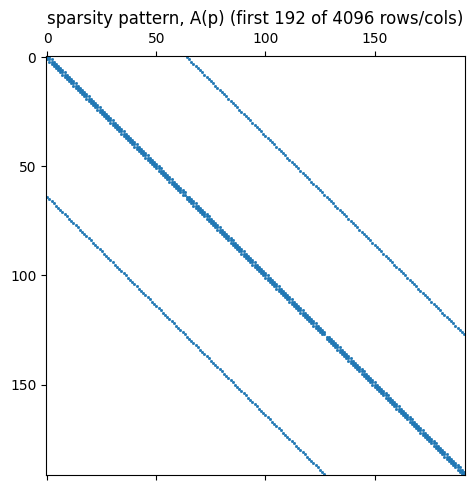

In [8]:
plt.figure(figsize=(5, 5))
# spy plot of a small sub-block so the 5-diagonal banded structure is visible
plt.spy(A[:3*ny, :3*ny], markersize=1)
plt.title(f"sparsity pattern, A(p) (first {3*ny} of {A.shape[0]} rows/cols)")
plt.tight_layout(); plt.show()

**CHECK:** the discrete Helmholtz operator must be symmetric (real,
Dirichlet BC) for `scipy.sparse.linalg.eigsh` (Section 6) to be the
correct solver -- `eigsh` assumes a Hermitian matrix and will silently
return wrong answers if handed a non-symmetric one, so this is checked
directly, not assumed.

In [9]:
A_dense = A.toarray()
asymmetry = np.max(np.abs(A_dense - A_dense.T))
print(f"max |A - A^T| = {asymmetry:.3e}")
assert asymmetry < 1e-10, "A(p) is not symmetric -- eigsh would give wrong results"
print("CHECK PASSED: A(p) is symmetric, eigsh (Section 6) is the appropriate solver")

max |A - A^T| = 0.000e+00
CHECK PASSED: A(p) is symmetric, eigsh (Section 6) is the appropriate solver


**INTERPRETATION:** the matrix is genuinely sparse (5 nonzeros per row
out of `nx*ny` columns) because the finite-difference stencil only couples
each grid point to its 4 immediate neighbors -- this is WHY sparse solvers
(Section 6) are the right tool instead of a dense eigensolver, not an
optimization detail.

**LIMITATION:** Dirichlet boundaries (`psi=0` fixed at the edge) are a
modeling choice, not a physical law -- they implicitly assume perfectly
absorbing/reflecting walls at the domain edge, which is only a good
approximation for a well-confined mode in a large-enough domain. No
eigenvalues have been computed yet; that's Section 6.

## 6. Eigenvalue Problem

**QUESTION:** Which eigenvectors of $A(p)$ from Section 5 are actual
GUIDED modes, and which eigenvalue should we even be solving for?

**PHYSICS:** Split the eigenproblem $\nabla^2\psi + k_0^2 n^2\psi=\beta^2\psi$
by region. In the uniform cladding ($n=n_{clad}$):
$\nabla^2\psi=(\beta^2-k_0^2n_{clad}^2)\psi$ -- for the field to DECAY
away from the core (not blow up), this requires $\beta^2 > k_0^2n_{clad}^2$.
In the core ($n=n_{core}$): $\nabla^2\psi=(\beta^2-k_0^2n_{core}^2)\psi$ --
for an oscillatory, bounded solution inside the core, this requires
$\beta^2 < k_0^2n_{core}^2$. So a physically guided mode must satisfy

$$k_0^2 n_{clad}^2 \;<\; \beta^2 \;<\; k_0^2 n_{core}^2
\qquad\Longleftrightarrow\qquad n_{clad} \;<\; n_{eff} \;<\; n_{core},
\quad n_{eff}\equiv\beta/k_0$$

which is exactly why we want the LARGEST eigenvalues of $A(p)$ -- they sit
just below $k_0^2n_{core}^2$ (the field's own diagonal ceiling), inside
the guided band, before dropping toward the continuum near $k_0^2n_{clad}^2$.

**MATH:** `scipy.sparse.linalg.eigsh(A, k=n_modes, which="LA")` -- "LA"
= largest algebraic eigenvalues, the ARPACK mode matched to the physics
above (NOT "LM"/largest magnitude, which would be wrong here since $A$
has no large negative eigenvalues to worry about, and NOT "SA", which
would return the least-confined/near-cladding numerical modes first).

**CODE:** `modes.py`'s `solve_modes` -- wraps `eigsh`, sorts
descending, reshapes each eigenvector back to the `(nx,ny)` grid, and
normalizes each mode so $\sum\psi^2\,dx\,dy=1$ (a SIMPLIFIED NUMERICAL
METRIC, not a rigorous optical-power normalization -- see Section 9). 9
tests (`test_modes.py`), including a direct check that the fundamental
mode's $n_{eff}$ falls strictly between $n_{clad}$ and $n_{core}$.

In [10]:
from modes import solve_modes

n_modes = 6
modes = solve_modes(n_rect, dx, dy, wavelength_um, n_modes=n_modes)

k0 = 2 * np.pi / wavelength_um
print(f"k0^2 n_clad^2 = {k0**2*1.44**2:.3f}   k0^2 n_core^2 = {k0**2*3.4**2:.3f}   (guided band)\n")
for i, m in enumerate(modes):
    print(f"mode {i}: beta^2={m['beta_sq']:.4f}  n_eff={m['n_eff']:.4f}")

k0^2 n_clad^2 = 34.074   k0^2 n_core^2 = 189.957   (guided band)

mode 0: beta^2=182.1658  n_eff=3.3295
mode 1: beta^2=176.5618  n_eff=3.2779
mode 2: beta^2=167.3435  n_eff=3.1912
mode 3: beta^2=164.8096  n_eff=3.1670
mode 4: beta^2=159.2119  n_eff=3.1127
mode 5: beta^2=154.6922  n_eff=3.0682


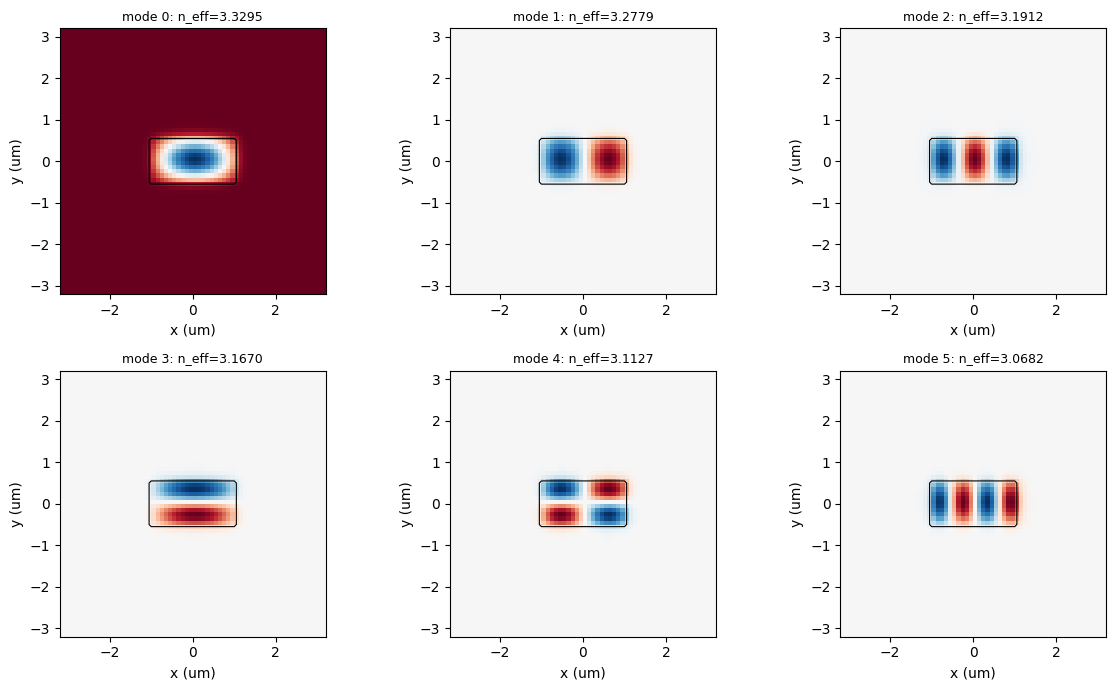

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(12, 7))
extent = [-domain_width/2, domain_width/2, -domain_height/2, domain_height/2]
for i, (ax, m) in enumerate(zip(axs.flat, modes)):
    im = ax.imshow(m["psi"].T, origin="lower", cmap="RdBu_r", extent=extent)
    ax.contour(X, Y, n_rect, levels=[(1.44 + 3.4) / 2], colors="k", linewidths=0.8)
    ax.set_title(f"mode {i}: n_eff={m['n_eff']:.4f}", fontsize=9)
    ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
plt.tight_layout(); plt.show()

**CHECK:** every returned mode's $n_{eff}$ must fall strictly inside
$(n_{clad}, n_{core})$ -- confirmed directly, not assumed from the solver
converging.

In [12]:
n_clad, n_core = 1.44, 3.4
all_guided = all(n_clad < m["n_eff"] < n_core for m in modes)
for i, m in enumerate(modes):
    in_band = n_clad < m["n_eff"] < n_core
    print(f"mode {i}: n_eff={m['n_eff']:.4f}  guided={in_band}")
assert all_guided, "at least one returned mode falls outside the physically guided band"
print("\nCHECK PASSED: all 6 modes are physically guided (not boundary/discretization artifacts)")

mode 0: n_eff=3.3295  guided=True
mode 1: n_eff=3.2779  guided=True
mode 2: n_eff=3.1912  guided=True
mode 3: n_eff=3.1670  guided=True
mode 4: n_eff=3.1127  guided=True
mode 5: n_eff=3.0682  guided=True

CHECK PASSED: all 6 modes are physically guided (not boundary/discretization artifacts)


**INTERPRETATION:** mode 0 (largest $n_{eff}$, closest to $n_{core}$) is
the fundamental mode -- a single lobe with no sign change, the most
tightly confined. Higher-indexed modes have progressively lower $n_{eff}$
and visibly more field lobes/sign changes (nodes) -- exactly the
particle-in-a-well pattern from Section 5's Schrodinger analogy: more
nodes = higher "energy" = less confined = closer to the edge of the
guided band.

**LIMITATION:** this is a FIXED-wavelength ($\lambda=1.55\,\mu m$)
snapshot at a FIXED geometry -- how $n_{eff}$ and confinement change as
geometry is swept comes in Section 10 (Parameter Sweep). The Dirichlet
domain boundary is finite, so in principle a few of the numerically
lowest-$n_{eff}$ "modes" near the top of the requested `n_modes` could be
boundary artifacts rather than true guided modes for some geometries --
which is exactly why the CHECK above is run every time, not assumed to
always pass.